# ILD-XR — Patient-Level Validation (Kaggle)

Full-volume sliding-window evaluation on a **15% patient hold-out** (seed 42), not the patch-level 88/12 split.

## Kaggle datasets (only these two required)

- **Volumes:** `romualdosebany/intertitial-lung-disease` → `ILD_DB/ILD_DB_volumeROIs`
- **Weights (Stage 2):** `harifraise/fine-tuning-second` → `best_finetuned_multiclass_model.pth`

`ildxr_kaggle.py` is **embedded in this notebook** (no separate upload needed).

## Exports (download after run)

- `/kaggle/working/exports/validation_metrics.json`
- `/kaggle/working/exports/validation_patient_rows.csv`
- `/kaggle/working/exports/figures/patient_{id}.png`
- `/kaggle/working/exports/figures/validation_grid.png` → copy to `Research/figures/fig6_qualitative.png`

In [1]:
from __future__ import annotations

import base64
import importlib.util
import shutil
import sys
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

ON_KAGGLE = Path("/kaggle/input").is_dir()
WORKSPACE = Path.cwd().resolve()
if WORKSPACE.name.lower() == "notebook":
    WORKSPACE = WORKSPACE.parent

STAGED = Path("/kaggle/working/ildxr_kaggle.py")
_EMBEDDED = """eNrlPe1y20aS//kUOFzVLpCAFEnZ3iwvTJViybZuZVklyZvs8lQoiBhSiEAAAUBJtFd/7wHuEe9JrrvnGwD1YW927+pciUQOenp6Zvp7eiDXdc9YuujP86yOkozFzuHRfv/nU+dmPBg7SbZgJcvmzFnkpfOnaLlMmeNluXMZza9ZFvejInFiVsBHgNr4A9d1e4syXzlhuFjX65KFoZOsirysnSjL8jqqkzyrej3R9kuVZ/JznawY71tE9VWaXMqOJ/CVP6g3RZItZftetgmc/WReB85RUsHPDwVij9LAOWO/rpHswDlfFyn8+pjBEzVstl4VGyeqnKyQTcUmTub5Sn49g98pOzz/E0JVSX2tqMzL+ZX1ZZBlhCprtg4W62zOKUKAN3wOJ4dHcgKHq2gpplzNE6BIkhcnjScD0SQh1lkCG7IKF0las1IAXlsgKxZVsP6Bs8rL4ipP8yWsVsWWK5bxXRBL+mu8kl3wc6/3r06/33eAHxbJ0vHURic7vGlQbHyE6J3snb9+F54d/vVgwld5lmSwCfLHhTN1vN1x4IzG39EPv3d2fnq4/wD06FXgvHqB//u910d7Z2fh0d6PB0dnE9pl3qGqS4T9PJo47nKZu4Ezhk8lq5P5OqV5QdMuNAG1VZ4mMW+77x0eh6/f7R0fEz5ABUjGveOP70Ma6UA1vuidH7w/OTjdO/94CrQu0jzC5uHgxUtB1Pm704Ozdx+O9i3CCFCSNhwMXxJl8OEPRA+23Pd67z7CeIcn4dGHnw5OAbg/2n0Jj1T7x5MTah9RawjNp3vHbw+gxYboOxam3tHH47cIrWhD3C+GgOL9h9OTd+H7vZ9pq6D5j3/shacfDsMf34bnH45gosevsXnE+iP+4M3bcP/g6HwPG4mK/YM3ex+PzsPzvdO3B+fh2cne68Pjt7RjgyHsrfjh98Lz073DY3gW7p+FJ6cHbw5/PjhDODeuxgPYGPi9O3B9ZLLz6BJ0yZ8PDw9Bt+TAxRPn5CqqmPNSaqAC9hO53FlGNWid1ycfA3g4B5gK5Pp8z/83BzSKZPTYyTOhoQa9870fjw5CRB6++fDh/OA0PBgfhGcHr8P3B3vACCcfcftfvRq86AB9DyuoYGnrhx1Qb06QPc8Pjl//BWDcV0Nnx3nx0llVbk/K0CqPWWqJELVUO+uM1buxkqR5GlWVc8qqJF5H6Y9pPr/e3fdAgbzP43XK/EnPgX8xW4BWTbKkDkOvAp2NghPOr0CvAs4JF6V8XdtNojP+q9YFKz1/oJD4+hGgG4DE3MBUYFyuPuskSj0Fgv/g0WsA2o09Y2R70MC5ZiV8CKvkE5vuBqDM4xiU9nTkB01cP0b1/OoYdhgQmjjakKfs6COMCRwxZ9Pzcs3aIIIwm5bfkLLG4lVXoEHna1QVX7lmI9/qnyzMbXb+ZWp1tUDhO8PxDmPcvHpjbHCD2pKla77V7ZXtKW4D4buNylgw291EWLZzBpq1BNb9wWrQjAbaeF1meiRPsZd35zvf2gsGTTCkkIGPxyAY+1ISvkQEUK4DNPAhYWSqFezKJaiOFvTu+GkiMh8FzhxQz4Fz5i+go4Wtgdz5BqloNr1oN31n7wv4LCNA3VQFFufMR36r07ijEye4DbvbBUsTa8AWeZ5yJnkf3Z3AF+Bhk1HHZI2TGD41el7mdZ2yjM2vu8aiBWz0WBe7fCiUlfMyyqoirxgMOH/Bl/xpA8ese3q7wHU0bnOOYI/0uDjcrsU8WyVTED3eQvQu55UnE925f2MketyxiWBMbaLHzyJ6tIVoHGr0DKJHnUyHRI86uHSRoB9skT16mOyv1kMMKVRyBYpGPxkbT8aeYnePjXwDateA2jWhxgbUpQTSXG+C7hqgMSJ8MwDFw8oiB/eGeZL7vUsf1hpnznZBN0YFm40nFwH5EFMX9iCF4CwqwYeK0mQJ+iCHtSqr6ZsIlH5jBCUKHl+XeVR7sxh4ku0CRogkpuYs4/E2osZevKuoGn8NVWODqrFFFXAYG3dRNdpG1ciLx4qq0ddQNTKoGllUAWeyUQdVYIypQ11CrAy+w8Syv2iYuWx2EA4PDMLjryFcj7W7baxdY+u+eizTnpMYezH4THK68sNu70F45RUXJSvKfM6qCmN59H/JrFdFNIeG8NPmLqzz8G7zyTOaZNBIUZYItmTMRRpg+2O+R9UnWA2MgO/QQ6MnXuVTWqMCT8AxxuKTF5PwqjvR8RNOgUidp0kRZuAdwsp9YuHV2rvJ0/WKTZysgEg9KstoQ0Tpr5wI7FhApDLFJ/hFdAzsaC6wgz2bHk8iaYSAPsQfKl70B1FVbwrmwTg0V/ByJPVJlddlXiTzsGRVhGkO7rByUvhia8K5wwsOIuyxXCPYm4f2g3cBpnh2n2/4L+RLVtUT55J7IMSSQa9zSXnOY0o5msFbVlNO5U2Zr/YQBucfVQTu6fkJgaauEOvUZ5xGr0byOnijNXuBIC+TJVkrGJ8jAwLO4LtnPi+sp2IoX64Rf75t5PYi+mKFbuXAs1V0540oieKV+ToDMwl+pZcDO2Q+/OPIQEjB2CLKT8B1ivBA0hgIWvwLwWycM0q5sqeigS8vZZ083wallcTJS+I6nn+g+chFEENuA9tPSkb5M08tn27yt3b7ADNKjD7ie1cHcn8wxeDRJPXXLuBDpWXzksPjj2POq8csWV5dwkqDhRDsy8MxBXhE6taSZcmzxKrIs7S6nh714I5BhMT4XHwl1ErRaummcfPaHhser4EtvgNvLC82XLP3eDQodIHKDSbzKA3TNfDYKqquwypN5mBL8Gdo64NOIbwEJV9ukFdED+d7p5WRIsi63GibOU+RWlSHOkcJAeMqv2FhBco1DfPLX2C/K48PAMYruuPuYSOtxZeV3c1ZUTvnsEYHZWl6gl8wEsRcXSOBeys8W43TzKoOqDkEVohBRAQM75BGlxj0TWXGakANNkzJlpggN4B4C1jMovI4BqG9+IaLDq3gG7boEyvzKkyTa72T4NEgB01Ns2AMOwD3uYYYbzNNo9VlHDnlxCkHQF0UAMgNuAcyR4CdkFO4KXvGSKiN+GiojMS4s8n4Qs8A8c7kYk0FDF8szK+OBkNTiERmfMA3DjPiaQgbzCoP8TxkCKM4KuoEOODL+X4Z3kTpmhmcPxsGzpAr0aQKwdeZw86BuQ7LPLFyQ2iZ0nSeQvClBpxNXgbO5CV4aRIzeGd1nk5bCVvfibJYj/+D0x8Phz2d6RF7o4cjS3hZqaHAfZC9fehuJX47F83MRzUn1rMyUE/UKr5BLiBFiEG1Bt0L5Azb/Pz8bbalIc/YE1hUsIamWXsNXreDZHifhtdkAAjOvuHJlC5/ZJusKCpaUgZ9t3VCeOliPq0HiuQnksYoWxKkiBeGF0ZqbAUot4sMdJp9utBcop5DKyozS7hZzFt5J/BWVuZecYhAoxCbEsUx8GuZRNlcpdBwXMtbhTnEyVon9zrFlucZ4DEHxmQdqnW5TeHi1QtOXZOrXom0FejmDCDsUzhPdBVRFx9Ew4fVr1u7ON9QvrDVD6bLN7L6FfQy/Ab7l6xARiTCPieFdx/6j4kB4ttxPPiFmDzMxY5Y/5Vkex2ZCbZ/PDB4YojGgeuoXDLlzT4Ej7zWfeokwoDfRuDA5oOLjYM/HI1q7307uD1ZXzEXhF/YoyMKIxHlJAQSuSnTIQGkq5DPbKuSQty839WawlQEbsesGqliNgndKWoCGQcWfAL9qzqaCwVFH72ZAAwURrBnwLfVdNhWa56YDqj8wUuTfclxtZi3MWRbQciF5GsC25BFqKs8tYS4MG0W5lAhqbzus+l/Lqs3tZfrujIacxQXcYOPJ41OnYspOfuHrz+8d5ZlEoP5F4FBJgIVXqrxKNN3cfHDfN+RSOHExlvYXu5Ma/NbwhDI8MZwQnM6cpO2zjM305Byg5sAC2gLygKBj6+CrVjYvASY1UQCDTyETrSFlCldGHs2AXwTQDi5w51U2Mx2k4mhi0qE6eIalQQDjohB4Nj8usiB5LCMbj3jKxbGTHgty6yqy4BKYzBNyW7ACMu8OP8mTLcVcAkiOBiO1USOEVYBVMwplplyTIFzi0xTV2GepRszQbg94PqykZT/xe7qMprXKOk1C+NkXhv9SSqwbdJTDmmSASgspQEWEAx3lF2NyMV91FAtkvWjmdnL2kUNIwnGU5IijBkrQjpDvAGS8iyEUApcboVlIkiy6Bc4P19PnBviNFBtN5SSVP0GSc1WFdhrEfRdo6ot6+o2qa+8zqIL/15QRhxF6WpQnFR+8ByGMp6YvMVTrvZhrWA3hAo5FOa1jE6e2OPGhkkeg0F8Hj/wFh5jXxc16ZkHlreLWZ4iSIFFrC9kmtdsTJsn0cYJ7NSoJLIOsKZGNZE/qHPPwq+xkzxYrA2z5Adt89oULw7NIEjzLEtI7WJ/6yvQORAIxRiSETawk5doU8N5fHVrO8fKYtrNCkfVLmjqNEEhcEjgwArewkpZ43EtKlwEKwzxPNHFN/QyDCR9r0vQ6yHieqxPK3ah5Q+TmCaCgqPnIwVHS3kRzps0zySCCwV1m1AOxkPoHxCf7/xOflOE6mgHpzrDPmgDJDZ9QCg7KBBAxD+rhZppp+h7dIUQamh7Pyw2lU0M9qlmhVdgpUqYskwUAIlnuoEDYGgBzLbiNUG4p0r3qbBLpZEVTkwka4QQOtjIfF8pbJhNnN+GXC1JT7tJhEklKzQpWL2JPHehFLpG4Hw/NXo3lfVMpFpgyVFP4ByMrn3dE6MjK/WalzXDE+Xa4zZ9GDjdPTFG4gT7vvM35zMOdW9ETChz4WKdplbMRCI6cVQBS2BEUm0XVC/rRBWxzro8UWSL4zwT6PjWPKvLY4odS9nm6zhyA2O1iHmr5nEMqXu2Am0cYaGvLpU06icD2+E3SDXCNYtAUxcp4KZS0l24IaLJmBrtwfBQsJledGdqfgGNoktbjXXGJB//ABC8lPWhOHObxrJ0p8q1cIpCeFKEV/jj1iLqt7CtqP5qqphQyLAiOKTiaJyEP1hn1a9rxj6BeGwxaAVYsphK6Yhs+HUr5HCIs8BTytgPdMMVNFyZDbfQcKuSgIQO15cQyg+3Wu4tot8M4KmnmwKHcGIPkHdFlfhEdNDhd8mKNAHHk7lqS+C//cB5Fzg/8V0RGI3Niebz9UqtlDBPoBkMo69w+NKDmrZXbJ6vs7qyEfEUHY3AgapYej1Kz+My8wZQeqZaxzQd73TV7nSlOo3sTiPZ6bbd6VZ1GtudxhdbHBN0RGXdex4uS9gWw+aqBCMWmHsNW7EfcL6vYlq1aj51/0wChO6QjpFc3661QJwbxNlA905IUHXV6CA73XV0+ok4ETrddnRSusLijNkEYrsApjWB/7/lU9jAlw19ucIIcwL/45fbi26cqFSJi6t8UaNAcPecxsLTfEO5ykqUTkRVii4NT2t7qBax8KP95VMgKVVNm0DSq5ruAkm13z0acekMxrxwvuWOVNUJx/lcAcpTm+hmGcqZc47HmfLSmxRiZ4/3owO4KRaV+3iigosNCzyBdZ3cXgzmxdrzB1xRKd2hLQeoQDIPei+NZ1OnWcUvEWgXrNW/kYnHs4THfVOLJvt4C8W/5birpTEcddM535IeQ73ewo7mqFwiUxlYRRLuwSybx0dVvcikmG4AtyMi7cYTGTzPdLjzwfEOj/bD/R/BH9vk69pXiQ2KeOiCjfSSgMsTBpFYnGDhP4RjW9K62xNnFyoddgTYndfneMnm3UfhZDneXwPnL4HzM08AiKwUSImqA/Kd1UolwdCHS1KG7CFcQ629SG1gFbZjEI2RRQm/eVC+GCQVIfD4cItBtV4skjsI9W6xUgLPMd1BPF+59qEXBvNyaMO5jRJY4jfQeJzXb7Cmg7Ir3sI9zh3E4nBagaLPBkn3wpyRIIP7lKJbbftZs4vnpDLB3UUxEM6WireSgK8GAwFE/cQ8OQVDe5KkiUtVSHLJwCYs7GNEXJWhrXAL7LZkEBvXpRcDz7onyR1LRcWIGzgzedvkwlZP5P/zAhqr+xkuxvlVMr8Gma1cflGl0VWvBulROX+vqNC2Gt/AaBozWC0BHGLMAikMaY0fOjit0rxg3USegtmLUnaGEC0SqbqP8mwP9T2UUNB/aPXn7DCICryl5yHV3whavtW4FUeai9FSg42Vatz+sc9b+WEAH1ypnsBEYWaollS6FNblur4ixddWEIFKqvNMfd0R7DSyFYKBJ/oEALBxx1riBuvjlnlCY7qmWEpwlGyS81bwqYQCQR+UN6VAhG7RuKUSMbCTOsmiFTOTfO6g6QDhhc0kWzNt48xMr0K0TQ+1/RwgulNkTf5uXDfpGgFmCdQWJKzu4JdC/mb8Q50s5O+F62+jgswXxlJUETUAZs2QErxCwsrac4/chgzbRnDrGqndkuIg6zDhNy+eg2F9Chl223bSqAznie8D+gXB5wNbY7BTtZ2FlrV5hEbA9qFZ45zDFIUt5xwYhyWZt6zVab4tQSpu2DQhR01IGSzcNSHHTUgZIbSPRpb1U85EhGTCEuL1IBBOHgdU2pNIKkrfSvmtvDiqo4YbQQklSmUbR2ZG3kcNswC/ipV04bhyYPvhM/dghJty+uGwIoP+7vT1eVgkaV7vKJ+hYpjPqlg9E5dSMZvEp4+ECYVAZNiqAC8BkZxI0mEHxSdUR3os11YLyEfYt0MldXI7jlUYaof3lSoH71uoQi/wAzxEf8c1T1LFyTKpPZ8nBHkreTpNAO4OCgC/pYAQZ6HoxYCet9hInii5mCCgnjQnxrIn9kPQQRTHHu9taw7cKqkNCsuI4RNpo0yuS+LtTIecYKVVZ4JitRfbGdi/EKPBcmFsvcYbshJ0i8OMKTnF43gq6txescwpc1hl8Ii5+SUOlkZuB1Qsw8RlhQIAaCHGJBvslHjRTh8Li80zXd5tllBXll5FADOnGoJsY/jQz/OPLZvZ6XQbbjRO7OlmXRIoOFF0fsrUFEGqjyTm6233dkOKa4L28osMqpgD8kWvNSfOa1WRJjZry+SobJiotykgd4NLpUsiajzZ4GlrfU9+9DKQ6jFWly/HVt2OEpVAS41W1Sd87H7KbljqYOjbR+tHlHItRSkS/lwzrHgJAlbTZgNKpYQVS3m5uHrDAR6EhpxsRMfvmCWxEfd9BmK8Ion5qT98MHkQIO+53sSzC5U4AO8EnvjO9864GcX9GSssVfgGS+LAMgGNEK+MlRk63K94mT7SFDhLmOJniVRGdZz0BH1+0A0hp7k5H4+eq22Zqk9YGJfFEH7TseMU96brPMQYRE4ykM/EqMb0OQfFWE0JSoQfg9JRiIcpDfuMcVnb3+UpmT4FUtl+89pOQYd1eJDYOFhbkkvRahZSvhyg+uG6hhsc+t6SbpmVanRTZqq719CuQOZB2XgwxOOywvmds/RFIesOfBcfvwXk8tOI9f+ojs6AB0CPZMLhqMJV6rVPaJ9zE6p5WKLlipV9fs1apEiAsVdHXG54yUufaoVucvD3Rf5OSRc1hqvVropCDZrAlcSg0mgYNRsMx7D7rRn3XIjTiB/kVdeDMgL59trnvKQZRwGWPO4am0ME412bjEolcbE5Ns0ihgePDqo698VTW+r9jTHPHWc0HDa2mruqvNgs5VVC4tSQkYgjq8IOTuS2LGv9bTuTA/cRIOgPYEhiWoGIt2xlQLMj67/aHl6I71gALjH3eVdkUvqg2LFM6k2YXz84F7wOkIYqNWmq//HLhmPy7Nkpc8UoFnxwpQVZli7DbklFEkzpKxwR276f2lTLCooEkKpzhoeObxsViO1z3O76iicdvAr7SOuoJPanKE1BZPP5tfP25OMOvrYEPDp8aUWfH2AYNWTkEoNjEVemCycy6+s4QhcnuomSFL1KoRrR1ImzKcthoRNgQ7QMLNUmm1+VeaZvudVDNESwiAMwAouQBEndDtt6QK5WOTCqKOwCT51L5Gdp4jSznZSfqk8d+beg4xBg2jwCMID0ocu0dZDt/wOX1TIuHcsLAlwPpRGhEpMY/A18vQS/3wD8we48lI4GP9rVH8Are3dJlPJQgR/kiSpz0ImrS3olWMqw3AqVMOOJOscTNU/OqN/ftYIGMaJMHqItFU0DftY+7bjdwdWZGGbqSLKdH6bOiEpvZMP3WNNvmmzeZ4uhVgOLfIezs+OMOV+Cv8JnPJUokDkAzBNfddKkP+L2nNIxI2t3hK0RRy0KqTLuPIyrGV60Ea+iUgGd5WfrLOcD+kfqENQePW3rSZnsZRtt6d+AtPWFkZcJFLSguB+aEjm4YeNJwV6tg0am98HjG79VRc0PSjkq4wRd7uH0CSlfuwjX38JcTzkyeZ/wi+YyGqSFMI9NKF5DL7tLxxtHcaJyv31JonvZ/P8tKtim/R+pjRtV3f/XNTLZWogp58oF3q6Wpe2THL/tboJcJpvfG4wkUooo+lrgG56k4UOL3I4JjN6Y6WVbVZN0sxL9B/Ode+3KSR5xiQl1lDmKYWfqoiYO6omQynjrBsxDw2wLHsXhtxhPh4tKSvnNFZ70acZPBoKWQALGrf3UaK1e3Cs2V9TWvF+7tgV6w1M1rY6K1CWH4OR3POcU6oX9bCWCXOEuuxOHH3MU5DuPG28+c8mZVkDLbiB0osGfVmBbHHTunVOIAUsyxGPCF01U+TVgMUIO3UcD3vesMvmenpNKyhASW6Hr/q7KpQIYxhbGI5I2l2fqrbsjvgmkuUGCmgxiQCoNES6LtVof1WqvpYu879KVAJMkIUbgv4XLGifGvxsQmmPh8WfaWvxgctjs+mKiuen6gt8raPLhfYA73tlX8NnWnvcmxbR/aiONJ+SWkkcETx/zUc2lCZVNhY7avhoASsbdiVa0JoDA6k6UEukJbuK3SZdLcGYbrpnwlZQjUua31YSnKBvy/pD3dbZerWAlGPe56D2XFb7oMqC3XQbOz4fK40LWpFHwgKjkl+PNfCM9wgKcwZLVnsHJ4j0dpD4vN1x7muqJaDYsA+mFiTPj+9mtlegyOKgly4qEql5R4hg+GQVnfDSSchVVukechgnRLzApJQveRVud1/S+sGFPvzeAAl69aEbeXY8kz3K4hQawWUMszRqOx2fSOtEijLaQXtDuEJ6Ooyx7IaWGxpI4+xwKvQTETWrBRNmkIDazG+3xLJ4Qw9mLEn/FCli705qEWh+uEi7E8DNU9BcdS2NsP+HiBwckP5a1RfmyjJqr4qgKdTLLPMUVHSr28/02JR3i/Wmlqfny4D1raPUMpvJ91N38XZyqkR996tL1DuxVHbeRQ+OX4TaWK8S6K23NjXXcsbYIbS4vrDa27RHc2iTjtzYMIdFAfByhXJ/LUtBSSTewwbPGSzmJH6RkbPVxsgc4wTSt2qjaMtmAfoAzkGrctl1aW5pDx5py52EbBzwNx711SMMXQuYW7vBIyzRflzCIfJuXeHNUI6+gzncm+uBNXE3hpzut9sdNofXqrquojG+jkicp8DLJ+M45Z1UaOecvHI+/ntkXl0vkrVJ+CVHFM7JgwrjggU2TxrQGq2s8fAUmRCVAN4IDWBM8Xc+vjQvCYtHwRPqpJl/6/Bs6FrfUDp2yoUZp7DIjHwyPOa12df7mToyTUf1Ybgc81kdvNozYGPSDxAFcg+v57U7B+wqL3wK7IaFFIIHI9LENKZdbCMDyo/FUbJpLG+yZW0h8bDZ06hl+sUD60fwajW/pGHnbQMLoyziWU863Fengn4JWYIBEztrXamGHH7xP64auf2/6GyZrGErCrak+4yZJkpC/wbzNF2zMyBbQ+zrmFBM8/mrylh6qrhSSTgTWC8sbvRdFFeKLIbP5prOv8RrzFjtw5YN/o4Hv59QQPyywaIvRAIFdu9vgFswEC2t2V3vYOIjXqwIFjsQLC4zwddVTfDUmUJnTK7nddb3ofydzcvPq5lECzE0aQAdOxBWLYnqJ3awzbOwMErfGcw2/IqQ/P9Bos/8QQeOh/ScJ7JgvRnQY0jWbAWNXM+JqtEOc08YBjW0My7rRX9yiTDKqgJ+5gTv4JU8yj6+ff9F0wS2r0CxRQwFrhiu270cDSZ+0fUvH/YxO5O/1Rv3+4j7gtw7VP9fq5j9cXrN9PDXTFhWzzlstwrtVHNRwGhRatD9u9zPUm51hySPgwvuhv3rxZGCLH5/cy2bUR7spb5/TNlPZpmf0tAn9IhQNqr8Ih5gAz4N9BfnPRtAifjuGiy2s71vK0lS77n9kgs1JErAGBZu6FK7hbioNLhzOBWhqs3KxUQQZGFVSvO7rb/ziqeXAYUEVXaT1NLT/dZWx8yiLceGYeCk/hkBGXhq0koLYUjkrX+shwXoPHymJAjXnMwxzTypvQYeivID4s6SYzpR4schaG6hGpcFXHgA+58JUxzuyxFkhrFfBkDUm4i7Xf//nfxkHXfSV6KZPZq0QHa/+g84P/85Hc/8PzsVoMPEyqK88g2q8oE/0tYACvWv6jVx5CghFVOA1dAHmSutoyfpj1C2sX6+x2EC/psXxxn3x1hXn3cdv5RvJdLmBEtjKcvFwBM/duaZoc4fe3ryDQlmxutqBmCZZkGzvyEGxnobXzuxQkhrbiZZwtU5Br9NhC7/zXNRXrrFRXSP9Nli76DffO9tP0rgvijL+OeN9ySh/f4xfT/fjY2t3mCr6NRdarnCha947rU1hJUF4BTvNKKReYegPhPx4/kCkObCuEuzgSZnj24pd/Mz/WFZ/hTkA/G78ZT76LgN2RbO8QOG5T2GTQJzidK+HcUM6n1O63pzPDo1lrglBPbIuBPOgBdaBjFQfYlRtiwfOXhw7D8q64z1h/r7xV8Vc693ZUrdJa99Ubl+im8p8tY7SOK/YZZRtduh2Zp3g3+Hqo/Hoi9OzHX5Haad1Vekx4fi7I/xCyjtGeIZMbXfgCmH1NmTJnyJPY5Kn4cv++2hD4vITY9cj+oRzow/vWfz28M25lLYG/fr9xXzU7VdJJETPlJenUviH/r+v002nxCtCdTrkEVqVGHYT+rgEtnE3Re+JDGGKl9/7H8FabGU="""


def _materialize_ildxr_module() -> Path:
    candidates = [
        WORKSPACE / "Notebook" / "ildxr_kaggle.py",
        Path.cwd() / "ildxr_kaggle.py",
        STAGED,
    ]
    if ON_KAGGLE:
        candidates = list(Path("/kaggle/input").rglob("ildxr_kaggle.py")) + candidates
    for src in candidates:
        if src.is_file():
            if ON_KAGGLE and src.resolve() != STAGED.resolve():
                STAGED.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(src, STAGED)
                return STAGED
            return src
    STAGED.parent.mkdir(parents=True, exist_ok=True)
    STAGED.write_bytes(zlib.decompress(base64.b64decode(_EMBEDDED)))
    return STAGED


def _load_ildxr():
    mod_path = _materialize_ildxr_module()
    spec = importlib.util.spec_from_file_location("ildxr_kaggle", mod_path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules["ildxr_kaggle"] = mod
    spec.loader.exec_module(mod)
    return mod


ildxr = _load_ildxr()
print(f"Kaggle: {ON_KAGGLE}")
print(f"Module: {ildxr.__file__}")

Kaggle: True
Module: /kaggle/working/ildxr_kaggle.py


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SPLIT_SEED = 42
SPLIT_TEST_SIZE = 0.15
EXPORT_DIR = Path("/kaggle/working/exports" if ON_KAGGLE else WORKSPACE / "Research" / "exports")
FIG_DIR = EXPORT_DIR / "figures"

WEIGHTS = ildxr.resolve_weights()
DATA_DIR = ildxr.resolve_data_dir()

CLASS_LABELS = ildxr.CLASS_LABELS
CLASS_COLORS = {
    0: (0.0, 0.0, 0.0, 0.0),
    1: (1.0, 0.85, 0.0, 0.55),
    2: (0.2, 0.6, 1.0, 0.55),
    3: (1.0, 0.2, 0.2, 0.55),
}

print(f"Device:   {DEVICE}")
print(f"Weights:  {WEIGHTS}")
print(f"Data dir: {DATA_DIR}")
print(f"Exports:  {EXPORT_DIR}")

Device:   cuda
Weights:  /kaggle/input/datasets/harifraise/segmentation-ild-classes/best_multiclass_model.pth
Data dir: /kaggle/input/datasets/romualdosebany/intertitial-lung-disease/ILD_DB/ILD_DB_volumeROIs
Exports:  /kaggle/working/exports


In [3]:
def make_class_overlay(mask_slice: np.ndarray) -> np.ndarray:
    overlay = np.zeros((*mask_slice.shape, 4), dtype=np.float32)
    for class_id, rgba in CLASS_COLORS.items():
        overlay[mask_slice == class_id] = rgba
    return overlay


def window_hu_slice(hu_slice: np.ndarray, center: float = -600.0, width: float = 1500.0) -> np.ndarray:
    lo, hi = center - width / 2, center + width / 2
    clipped = np.clip(hu_slice, lo, hi)
    return (clipped - lo) / (hi - lo)


def error_map_slice(pred_slice: np.ndarray, gt_slice: np.ndarray) -> np.ndarray:
    err = np.zeros((*pred_slice.shape, 3), dtype=np.float32)
    fp = (pred_slice != gt_slice) & (pred_slice > 0)
    fn = (pred_slice != gt_slice) & (gt_slice > 0)
    err[fp] = (1.0, 0.2, 0.2)
    err[fn] = (0.2, 0.6, 1.0)
    return err


def save_patient_figure(
    patient_id: str,
    volume_hu: np.ndarray,
    pred_mask: np.ndarray,
    gt_mask: np.ndarray,
    slice_index: int,
    out_path: Path,
) -> None:
    z_idx = int(np.clip(slice_index, 0, volume_hu.shape[0] - 1))
    hu_disp = window_hu_slice(volume_hu[z_idx])
    pred_slice = pred_mask[z_idx]
    gt_slice = gt_mask[z_idx]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"Patient {patient_id} — z={z_idx}", fontsize=12)

    axes[0].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("CT")
    axes[0].axis("off")

    axes[1].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[1].imshow(make_class_overlay(gt_slice))
    axes[1].set_title("GT overlay")
    axes[1].axis("off")

    axes[2].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(make_class_overlay(pred_slice))
    axes[2].set_title("Pred overlay")
    axes[2].axis("off")

    axes[3].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[3].imshow(error_map_slice(pred_slice, gt_slice), alpha=0.7)
    axes[3].set_title("Error (FP red / FN blue)")
    axes[3].axis("off")

    legend_patches = [
        mpatches.Patch(color=CLASS_COLORS[c][:3], label=CLASS_LABELS.get(c, str(c)))
        for c in (1, 2, 3)
    ]
    axes[-1].legend(handles=legend_patches, loc="lower right", fontsize=8)
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close(fig)


def build_validation_grid(per_patient_paths: list[Path], out_path: Path, cols: int = 2) -> None:
    if not per_patient_paths:
        return
    imgs = [plt.imread(p) for p in per_patient_paths]
    rows = int(np.ceil(len(imgs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 3.5 * rows))
    axes = np.atleast_2d(axes)
    for idx, img in enumerate(imgs):
        r, c = divmod(idx, cols)
        axes[r, c].imshow(img)
        axes[r, c].set_title(per_patient_paths[idx].stem.replace("patient_", "Patient "), fontsize=10)
        axes[r, c].axis("off")
    for idx in range(len(imgs), rows * cols):
        r, c = divmod(idx, cols)
        axes[r, c].axis("off")
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

In [4]:
all_ids = ildxr.list_patient_ids(DATA_DIR)
train_ids, val_ids = ildxr.split_patient_ids(all_ids, test_size=SPLIT_TEST_SIZE, seed=SPLIT_SEED)

print(f"Cohort folders: {len(all_ids)}")
print(f"Train patients: {len(train_ids)}")
print(f"Val patients:   {len(val_ids)} -> {val_ids}")

model = ildxr.load_trained_model(WEIGHTS, DEVICE)
print(f"Model loaded on {DEVICE} from {WEIGHTS.name}")

Cohort folders: 113
Train patients: 96
Val patients:   17 -> ['3', '17', '36', '37', '48', '89', '101', '112', '118', '140', '144', '147', '150', '160', '164', '182', '210']
Model loaded on cuda from best_multiclass_model.pth


In [5]:
patient_rows: list[dict] = []
figure_paths: list[Path] = []

for pid in val_ids:
    print("=" * 60)
    print(f"Validation patient {pid}")
    patient_dir = ildxr.find_patient_dir(DATA_DIR, pid)

    if not ildxr.is_evaluable_patient(patient_dir):
        print(f"  SKIP (not evaluable: missing CT or roi_mask)")
        patient_rows.append({"patient_id": pid, "evaluable": False})
        continue

    metrics = ildxr.evaluate_validation_patient(patient_dir, model, DEVICE)
    patient_rows.append(metrics)

    volume_hu = metrics["_volume_hu"]
    pred_mask = metrics["_pred_mask"]
    gt_mask = metrics["_gt_mask"]

    fig_path = FIG_DIR / f"patient_{pid}.png"
    save_patient_figure(pid, volume_hu, pred_mask, gt_mask, metrics["best_slice"], fig_path)
    figure_paths.append(fig_path)

    print(f"  infer_sec_gpu={metrics['infer_sec_gpu']:.2f}s")
    for label in CLASS_LABELS.values():
        d = metrics["dice"][label]
        print(f"  Dice {label:14s}: {d:.4f}")

evaluable = [r for r in patient_rows if r.get("evaluable")]
print(f"\nCompleted {len(evaluable)} / {len(val_ids)} validation patients")

Validation patient 3


Volumetric inference: 100%|██████████| 1/1 [00:03<00:00,  3.87s/it]


  infer_sec_gpu=4.60s
  Dice ggo           : 1.0000
  Dice reticulation  : 1.0000
  Dice consolidation : 0.2899
Validation patient 17


Volumetric inference: 100%|██████████| 1/1 [00:02<00:00,  2.46s/it]


  infer_sec_gpu=3.12s
  Dice ggo           : 0.0000
  Dice reticulation  : 0.3658
  Dice consolidation : 0.1712
Validation patient 36


...

  infer_sec_gpu=2.21s
  Dice ggo           : 0.6386
  Dice reticulation  : 0.0000
  Dice consolidation : 0.0000
Validation patient 182


Volumetric inference: 100%|██████████| 3/3 [00:05<00:00,  1.95s/it]


  infer_sec_gpu=6.56s
  Dice ggo           : 0.0000
  Dice reticulation  : 1.0000
  Dice consolidation : 0.3648
Validation patient 210


Volumetric inference: 100%|██████████| 1/1 [00:01<00:00,  1.64s/it]


  infer_sec_gpu=2.25s
  Dice ggo           : 1.0000
  Dice reticulation  : 0.5163
  Dice consolidation : 0.0000

Completed 17 / 17 validation patients


Ranking by macro Dice on GT-present classes (* = present in GT)

BEST  → patient 160  |  ggo=1.000- | ret=0.754* | con=0.774*
WORST → patient 101  |  ggo=1.000- | ret=1.000- | con=0.000*

Top 3 / bottom 3:
  ↑ 160  macro=0.764  ggo=1.000- | ret=0.754* | con=0.774*
  ↑ 118  macro=0.696  ggo=0.000- | ret=1.000- | con=0.696*
  ↑ 164  macro=0.639  ggo=0.639* | ret=0.000- | con=0.000-
  ↓ 101  macro=0.000  ggo=1.000- | ret=1.000- | con=0.000*
  ↓  89  macro=0.000  ggo=1.000- | ret=1.000- | con=0.000*
  ↓  48  macro=0.210  ggo=1.000- | ret=1.000- | con=0.210*


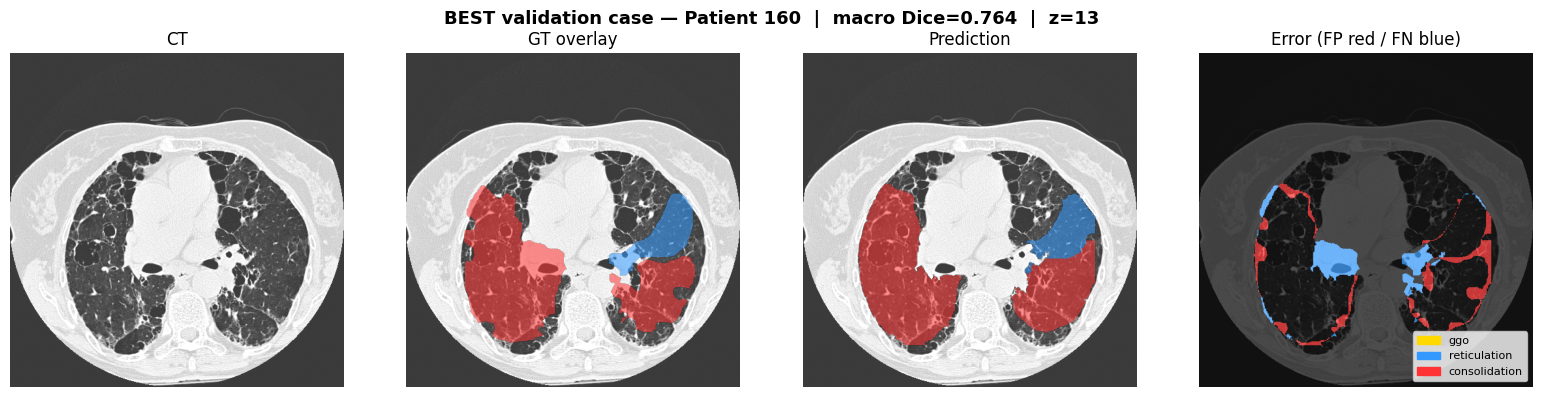

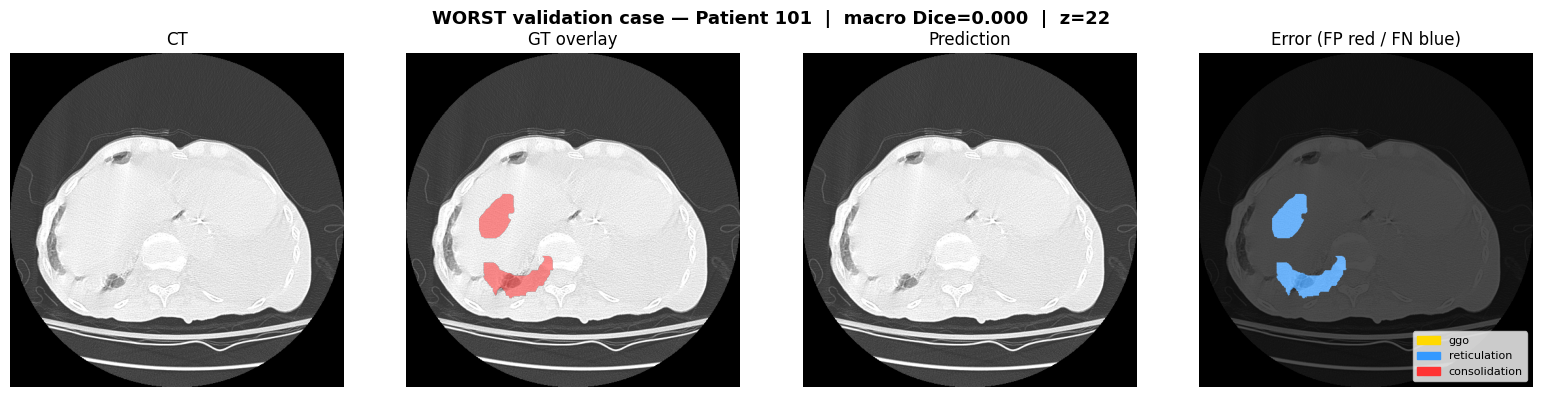

In [6]:
def macro_dice_present(row: dict) -> float:
    """Mean Dice over classes with GT foreground (ignores absent-class trivial 1.0)."""
    vals = [
        float(row["dice"][label])
        for label in CLASS_LABELS.values()
        if row.get("present_in_gt", {}).get(label, False)
    ]
    return float(np.mean(vals)) if vals else 0.0


def dice_summary(row: dict) -> str:
    parts = []
    for label in CLASS_LABELS.values():
        mark = "*" if row.get("present_in_gt", {}).get(label, False) else "-"
        parts.append(f"{label[:3]}={row['dice'][label]:.3f}{mark}")
    return " | ".join(parts)


def display_patient_case(row: dict, title: str) -> None:
    pid = row["patient_id"]
    volume_hu = row["_volume_hu"]
    pred_mask = row["_pred_mask"]
    gt_mask = row["_gt_mask"]
    z_idx = int(row["best_slice"])

    hu_disp = window_hu_slice(volume_hu[z_idx])
    pred_slice = pred_mask[z_idx]
    gt_slice = gt_mask[z_idx]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(
        f"{title} — Patient {pid}  |  macro Dice={macro_dice_present(row):.3f}  |  z={z_idx}",
        fontsize=13,
        fontweight="bold",
    )

    axes[0].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("CT")
    axes[0].axis("off")

    axes[1].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[1].imshow(make_class_overlay(gt_slice))
    axes[1].set_title("GT overlay")
    axes[1].axis("off")

    axes[2].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[2].imshow(make_class_overlay(pred_slice))
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    axes[3].imshow(hu_disp, cmap="gray", vmin=0, vmax=1)
    axes[3].imshow(error_map_slice(pred_slice, gt_slice), alpha=0.7)
    axes[3].set_title("Error (FP red / FN blue)")
    axes[3].axis("off")

    legend_patches = [
        mpatches.Patch(color=CLASS_COLORS[c][:3], label=CLASS_LABELS.get(c, str(c)))
        for c in (1, 2, 3)
    ]
    axes[-1].legend(handles=legend_patches, loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()


eval_rows = [r for r in patient_rows if r.get("evaluable")]
if not eval_rows:
    raise RuntimeError("No evaluable validation patients — run the evaluation cell first.")

ranked = sorted(eval_rows, key=macro_dice_present, reverse=True)
best_row = ranked[0]
worst_row = ranked[-1]

print("Ranking by macro Dice on GT-present classes (* = present in GT)\n")
print(f"BEST  → patient {best_row['patient_id']}  |  {dice_summary(best_row)}")
print(f"WORST → patient {worst_row['patient_id']}  |  {dice_summary(worst_row)}")

print("\nTop 3 / bottom 3:")
for row in ranked[:3]:
    print(f"  ↑ {row['patient_id']:>3s}  macro={macro_dice_present(row):.3f}  {dice_summary(row)}")
for row in ranked[-3:][::-1]:
    print(f"  ↓ {row['patient_id']:>3s}  macro={macro_dice_present(row):.3f}  {dice_summary(row)}")

display_patient_case(best_row, "BEST validation case")
display_patient_case(worst_row, "WORST validation case")

In [7]:
json_path = ildxr.export_validation_bundle(
    EXPORT_DIR,
    train_ids,
    val_ids,
    patient_rows,
    hardware="2x Tesla T4 (Kaggle)" if ON_KAGGLE else DEVICE,
    weights_path=WEIGHTS,
)
grid_path = FIG_DIR / "validation_grid.png"
build_validation_grid(figure_paths, grid_path, cols=2)

print(f"Wrote {json_path}")
print(f"Wrote {EXPORT_DIR / 'validation_patient_rows.csv'}")
print(f"Wrote {grid_path}")
print(f"Per-patient figures: {len(figure_paths)}")

Wrote /kaggle/working/exports/validation_metrics.json
Wrote /kaggle/working/exports/validation_patient_rows.csv
Wrote /kaggle/working/exports/figures/validation_grid.png
Per-patient figures: 17


In [8]:
summary = ildxr.aggregate_validation_metrics(patient_rows)
print("=== Table VII (full-volume Dice summary) ===")
for label in CLASS_LABELS.values():
    d = summary["dice"][label]
    print(f"  {label:14s}  present={d['present']:2d}  mean={d['mean']}  std={d['std']}")

print("\n=== Table VIII (GPU infer) ===")
print(f"  mean infer_sec_gpu = {summary['infer_sec_gpu_mean']} s (std {summary['infer_sec_gpu_std']})")

print("\n=== Table XI (biomarker parity) ===")
print(f"  pass rate = {summary['parity_pass_rate']:.1%} ({summary['parity_pass']}/{summary['parity_total']})")

print("\nCopy exports to repo:")
print("  Research/exports/validation_metrics.json")
print("  Research/figures/fig6_qualitative.png  <- validation_grid.png")
print("Then run: python Research/scripts/update_tables_from_exports.py")

=== Table VII (full-volume Dice summary) ===
  ggo             present= 2  mean=0.717  std=0.418
  reticulation    present= 3  mean=0.861  std=0.284
  consolidation   present=15  mean=0.271  std=0.226

=== Table VIII (GPU infer) ===
  mean infer_sec_gpu = 2.58 s (std 1.27)

=== Table XI (biomarker parity) ===
  pass rate = 66.7% (34/51)

Copy exports to repo:
  Research/exports/validation_metrics.json
  Research/figures/fig6_qualitative.png  <- validation_grid.png
Then run: python Research/scripts/update_tables_from_exports.py


In [9]:
import os
import shutil
from IPython.display import FileLink

# 1. Force notebook into the working directory
os.chdir('/kaggle/working')

# 2. Setup names
output_filename = 'all_kaggle_working_files'
output_zip = f"{output_filename}.zip"

# 3. Create a temporary folder to cleanly gather everything
temp_dir = '/kaggle/working/tmp_download_bundle'
os.makedirs(temp_dir, exist_ok=True)

print("Gathering all files from /kaggle/working/...")
# Copy everything except our temporary folder and any existing massive zips
for item in os.listdir('.'):
    if item == 'tmp_download_bundle' or item.endswith('.zip'):
        continue
    
    try:
        if os.path.isdir(item):
            shutil.copytree(item, os.path.join(temp_dir, item), dirs_exist_ok=True)
        else:
            shutil.copy2(item, os.path.join(temp_dir, item))
    except Exception as e:
        print(f"Skipping {item}: {e}")

# 4. Zip the gathered contents
print("Compressing everything into a single archive...")
shutil.make_archive(output_filename, 'zip', temp_dir)

# Clean up the temporary folder workspace
shutil.rmtree(temp_dir)

# 5. Provide the direct download link
if os.path.exists(output_zip):
    print("\n✨ Done! Click the blue link below to download everything in your working directory:")
    display(FileLink(output_zip))
else:
    print("\n❌ Error: Failed to create the archive.")

Gathering all files from /kaggle/working/...
Compressing everything into a single archive...

✨ Done! Click the blue link below to download everything in your working directory:


/kaggle/working/all_kaggle_working_files.zip